In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Dades
data = {'temperatures':[18,21,24,27,29,33,17,22],
        'vendes':[58,63,69,70,76,78,57,65]}

gelats = pd.DataFrame(data)

X= gelats[['temperatures']]
y= gelats[['vendes']]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.5, l1_ratio=0.5)
}

for nom, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{nom:10} → MSE: {mean_squared_error(y_test, pred):.3f}")


Linear     → MSE: 0.857
Ridge      → MSE: 0.833
Lasso      → MSE: 0.848
ElasticNet → MSE: 0.807


Linear     → MSE: 3.378
Ridge      → MSE: 3.386
Lasso      → MSE: 3.748
ElasticNet → MSE: 4.139


<Figure size 1000x600 with 0 Axes>

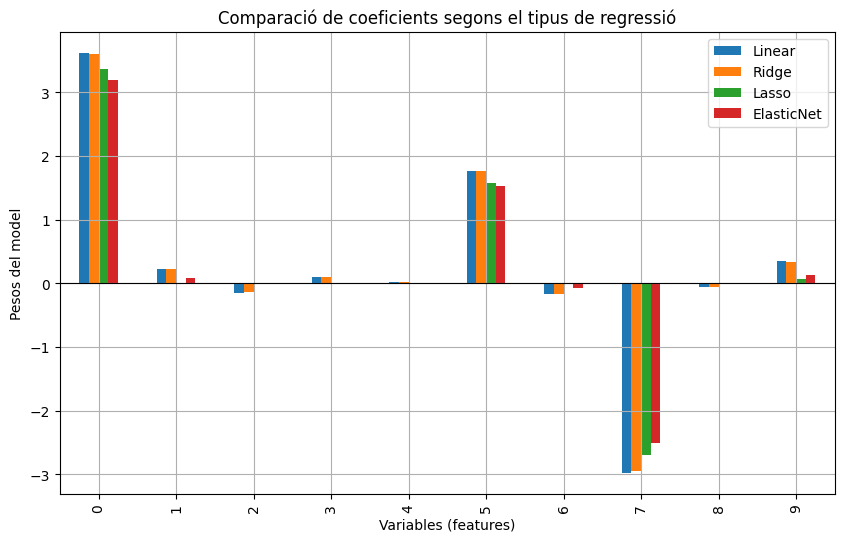

Coeficients reals vs. estimats:


,Linear,Ridge,Lasso,ElasticNet,Real
0,3.62,3.60,3.37,3.19,4
1,0.22,0.22,0.00,0.08,0
2,-0.15,-0.14,-0.00,-0.00,0
3,0.10,0.09,0.00,0.00,0
4,0.03,0.02,0.00,-0.00,0
5,1.77,1.76,1.58,1.53,2
6,-0.17,-0.17,-0.00,-0.07,0
7,-2.98,-2.95,-2.70,-2.51,-3
8,-0.05,-0.05,-0.00,-0.00,0
9,0.34,0.34,0.07,0.13,0


In [10]:
# ===============================================
# Comparació de Linear, Ridge, Lasso i ElasticNet
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1️⃣ Generem dades artificials
np.random.seed(42)
n_samples = 200
n_features = 10

X = np.random.randn(n_samples, n_features)

# Només 3 variables són rellevants (X0, X5, X7)
true_coefs = np.array([4, 0, 0, 0, 0, 2, 0, -3, 0, 0])
y = X @ true_coefs + np.random.randn(n_samples) * 2.0

# Escalem les dades (important per regularització)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2️⃣ Dividim dades
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3️⃣ Definim els models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.2),
    "ElasticNet": ElasticNet(alpha=0.2, l1_ratio=0.5)
}

# 4️⃣ Entrenem els models
coefs = pd.DataFrame()
for name, model in models.items():
    model.fit(X_train, y_train)
    coefs[name] = model.coef_

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name:10} → MSE: {mean_squared_error(y_test, y_pred):.3f}")

# 5️⃣ Visualitzem els coeficients
plt.figure(figsize=(10,6))
coefs.plot(kind='bar', figsize=(10,6))
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Comparació de coeficients segons el tipus de regressió")
plt.xlabel("Variables (features)")
plt.ylabel("Pesos del model")
plt.grid(True)
plt.show()

# 6️⃣ Mostrem els valors reals dels coeficients per comparar
coefs['Real'] = true_coefs
print("Coeficients reals vs. estimats:")
display(coefs.round(2))


Linear     → MSE: 3.378
Ridge005   → MSE: 3.379
Lasso005   → MSE: 3.449
ElasticNet005 → MSE: 3.507
Ridge1     → MSE: 3.386
Lasso1     → MSE: 8.477
ElasticNet1 → MSE: 8.477


<Figure size 1000x600 with 0 Axes>

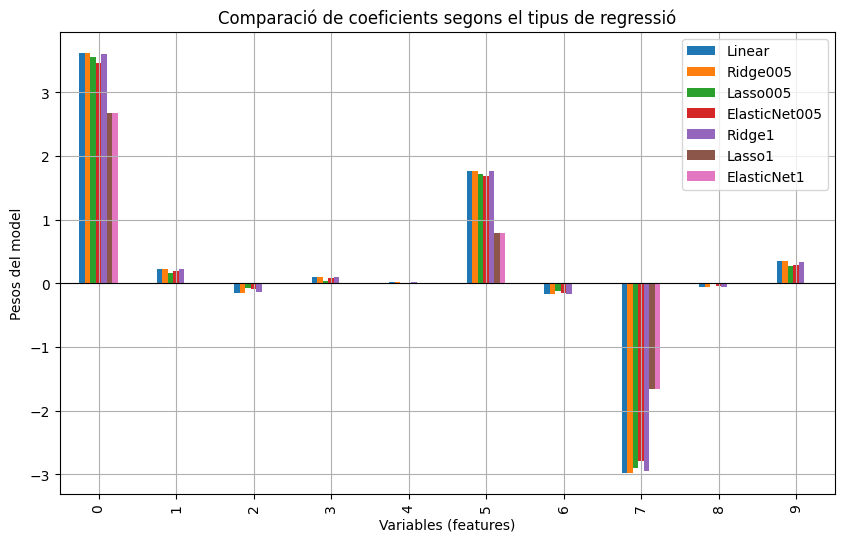

Coeficients reals vs. estimats:


,Linear,Ridge005,Lasso005,ElasticNet005,Ridge1,Lasso1,ElasticNet1,Real
0,3.62,3.62,3.55,3.46,3.60,2.68,2.68,4
1,0.22,0.22,0.17,0.20,0.22,0.00,0.00,0
2,-0.15,-0.15,-0.07,-0.09,-0.14,0.00,0.00,0
3,0.10,0.10,0.04,0.09,0.09,0.00,0.00,0
4,0.03,0.03,0.00,0.00,0.02,-0.00,-0.00,0
5,1.77,1.77,1.72,1.69,1.76,0.80,0.80,2
6,-0.17,-0.17,-0.12,-0.16,-0.17,-0.00,-0.00,0
7,-2.98,-2.98,-2.91,-2.79,-2.95,-1.66,-1.66,-3
8,-0.05,-0.05,-0.00,-0.04,-0.05,-0.00,-0.00,0
9,0.34,0.34,0.28,0.29,0.34,0.00,0.00,0


In [12]:
# ===============================================
# Comparació de Linear, Ridge, Lasso i ElasticNet
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1️⃣ Generem dades artificials
np.random.seed(42)
n_samples = 200
n_features = 10

X = np.random.randn(n_samples, n_features)

# Només 3 variables són rellevants (X0, X5, X7)
true_coefs = np.array([4, 0, 0, 0, 0, 2, 0, -3, 0, 0])
y = X @ true_coefs + np.random.randn(n_samples) * 2.0

# Escalem les dades (important per regularització)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2️⃣ Dividim dades
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3️⃣ Definim els models
models = {
    "Linear": LinearRegression(),
    "Ridge005": Ridge(alpha=0.05),
    "Lasso005": Lasso(alpha=0.05),
    "ElasticNet005": ElasticNet(alpha=0.05, l1_ratio=0.05),
    "Ridge1": Ridge(alpha=1),
    "Lasso1": Lasso(alpha=1),
    "ElasticNet1": ElasticNet(alpha=1, l1_ratio=1)
}

# 4️⃣ Entrenem els models
coefs = pd.DataFrame()
for name, model in models.items():
    model.fit(X_train, y_train)
    coefs[name] = model.coef_

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name:10} → MSE: {mean_squared_error(y_test, y_pred):.3f}")

# 5️⃣ Visualitzem els coeficients
plt.figure(figsize=(10,6))
coefs.plot(kind='bar', figsize=(10,6))
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Comparació de coeficients segons el tipus de regressió")
plt.xlabel("Variables (features)")
plt.ylabel("Pesos del model")
plt.grid(True)
plt.show()

# 6️⃣ Mostrem els valors reals dels coeficients per comparar
coefs['Real'] = true_coefs
print("Coeficients reals vs. estimats:")
display(coefs.round(2))
